<a href="https://colab.research.google.com/github/whistle-hikhi/Logistic-Regression/blob/main/logistic_resgression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed Apr  2 03:54:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%load_ext cuml.accel

[2025-04-02 03:55:05.065] [CUML] [info] cuML: Installed accelerator for sklearn.
[2025-04-02 03:55:43.601] [CUML] [info] cuML: Installed accelerator for umap.
[2025-04-02 03:55:43.754] [CUML] [info] cuML: Installed accelerator for hdbscan.
[2025-04-02 03:55:43.754] [CUML] [info] cuML: Successfully initialized accelerator.


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
def create_sample_data():
  np.random.seed(18)
  n_samples = 100

  study_hours = np.random.uniform(1, 10, n_samples)
  prev_scores = np.random.uniform(0, 100, n_samples)

  pass_probability = 1 / (1 + np.exp(-(study_hours * 0.5 + prev_scores * 0.05 - 5)))
  y = (pass_probability > 0.5).astype(int)

  data = pd.DataFrame({
      'study_hours': study_hours,
      'prev_scores': prev_scores,
      'passed': y
  })
  return data

def prepare_data(data):
  X = data[['study_hours', 'prev_scores']]
  y = data['passed']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=18
  )

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  return X_train_scaled, X_test_scaled, y_train, y_test, scaler

def train_evaluate_model(X_train, X_test, y_train, y_test):
  model = LogisticRegression(random_state=18)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)

  return model, y_pred, accuracy

def plot_results(data, model, scaler):
  h = 0.002
  X = data[['study_hours', 'prev_scores']]
  X_scaled = scaler.transform(X)

  x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
  y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

  xx, yy = np.meshgrid(
      np.arange(x_min, x_max, h),
      np.arange(y_min, y_max, h)
  )

  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)


  plt.figure(figsize=(10,6))
  plt.contourf(xx, yy, Z, alpha=0.4)
  plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=data['passed'], alpha=0.8)
  plt.xlabel('Scaled Study Hours')
  plt.ylabel('Scaled Previous Scores')
  plt.title('Logistic Regression Decision Boundary')
  plt.colorbar(label='Pass (1), Fail (0)')
  plt.show()

In [15]:
data = create_sample_data()

In [16]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_data(data)

In [17]:
model, y_pred, accuracy = train_evaluate_model(
    X_train_scaled, X_test_scaled, y_train, y_test
)

[2025-04-02 04:18:29.048] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization


In [18]:
print('\nModel Results:')
print(f'Accuracy: {accuracy}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Model Results:
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [19]:
print('\nModel Coefficients:')
print(f'Study Hours: {model.coef_[0][0]}')
print(f'Previous Scores: {model.coef_[0][1]}')
print(f'Intercept: {model.intercept_[0]}')


Model Coefficients:
Study Hours: 2.471846931743927
Previous Scores: 2.5239927649742273
Intercept: 0.8963829837295033


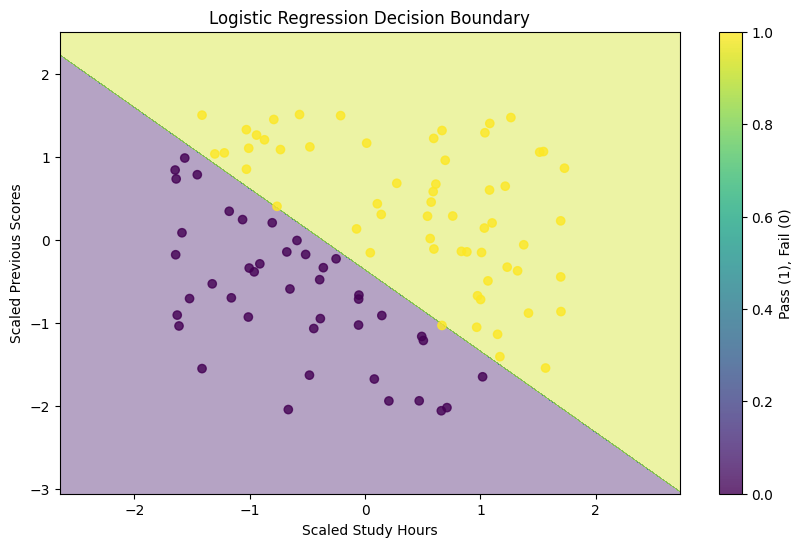

In [20]:
plot_results(data, model, scaler)